## Source

- Energy consumption data obtained from Appendix I: Detailed Energy Balance from page 52 of the 2023 MEMD Statistical Abstract
- Energy consumption transition data obtained from Uganda Energy Transition Plan Figure 2.3 in page 30

In [79]:
import sys
import warnings
warnings.filterwarnings("ignore")
dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)

import utils.common_data_needs as cdn
import numpy as np
import pandas as pd
import os
import utils.shared_data_memd as sdm
from utils.utils import *

In [15]:

# get SISEPUEDE elements
dict_ssp = cdn._setup_sisepuede_elements()
examples = cdn._SISEPUEDE_EXAMPLES
struct = cdn._SISEPUEDE_FILE_STRUCTURE

# shortcuts
matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

In [3]:
%load_ext autoreload
%autoreload 2

In [80]:
edau = EDAUtils()
gu = GeneralUtils()

In [81]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")

In [82]:
# --- Select sector and set up years ---
fuel_share_sector_type = "Transport"
transport_cat = "road_heavy_freight"
years_full = np.arange(2015, 2101)

In [83]:
# load final energy consumption by fuel data
fuel_share_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "inen","fuel_share_pj.csv"))
fuel_share_df

,Sector,Year,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste
0,Industry,2015,30.00,3,0,8.0,110
1,Industry,2021,35.00,5,0,10.0,100
2,Industry,2030,47.00,15,15,50.0,60
3,Industry,2050,40.00,25,35,215.0,60
4,Industry,2070,35.00,20,25,250.0,50
5,Industry,2100,30.00,15,15,280.0,40
6,Residential,2015,0.05,0,0,0.8,450
7,Residential,2021,0.10,0,0,1.0,430
8,Residential,2030,60.00,0,0,50.0,120
9,Residential,2050,70.00,0,0,187.0,33


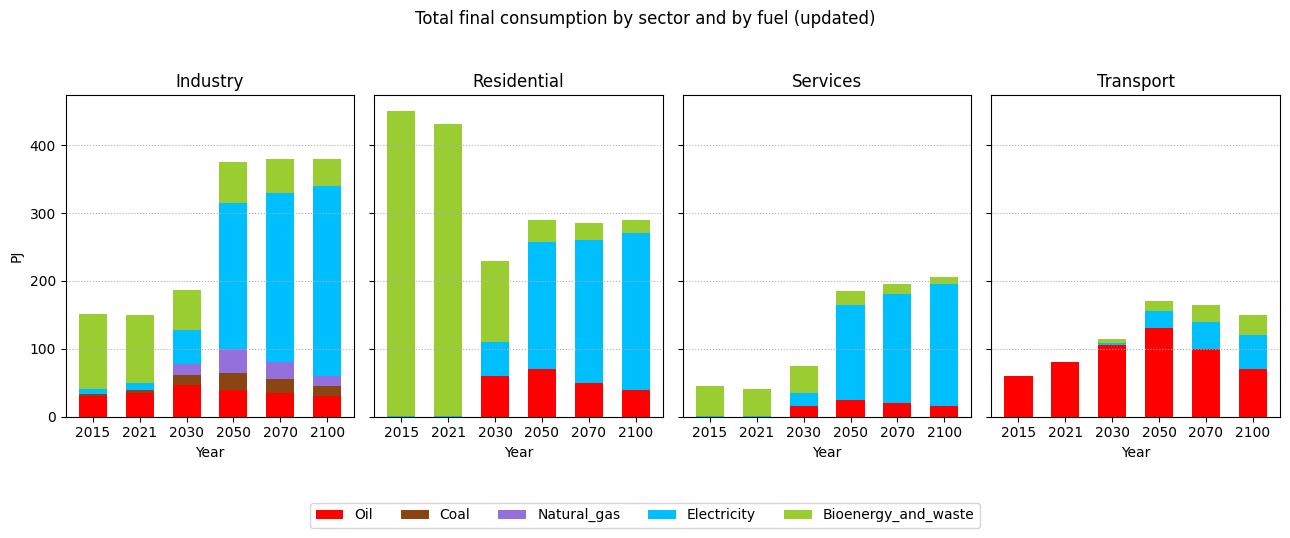

In [84]:
# Set color map matching the original plot
fuel_colors = {
    'Oil': 'red',
    'Coal': 'saddlebrown',
    'Natural_gas': 'mediumpurple',
    'Electricity': 'deepskyblue',
    'Bioenergy_and_waste': 'yellowgreen'
}

# Plotting
sectors = fuel_share_df['Sector'].unique()
years = [2015, 2021, 2030, 2050, 2070, 2100]
fuels = ['Oil', 'Coal', 'Natural_gas', 'Electricity', 'Bioenergy_and_waste']

fig, axes = plt.subplots(1, len(sectors), figsize=(13,5), sharey=True)

bar_width = 0.6  # Wider bars

for i, sector in enumerate(sectors):
    ax = axes[i]
    sector_data = fuel_share_df[fuel_share_df['Sector'] == sector].sort_values('Year')
    x = range(len(years))
    bottom = [0] * len(years)
    for fuel in fuels:
        ax.bar(x, sector_data[fuel], width=bar_width, bottom=bottom, label=fuel if i == 0 else "", color=fuel_colors[fuel])
        bottom = [a + b for a, b in zip(bottom, sector_data[fuel])]
    ax.set_title(sector)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    if i == 0:
        ax.set_ylabel('PJ')
    ax.set_xlabel('Year')
    ax.grid(axis='y', linestyle=':')

fig.suptitle('Total final consumption by sector and by fuel (updated)')
fig.legend(fuels, loc='lower center', ncol=len(fuels), bbox_to_anchor=(0.5, -0.07))
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [113]:
importlib.reload(sdm)


,Sector,Oil Products Total,LPG,Gasoline,Jet Kerosene,Other Kerosene,Diesel,Fuel oil,Solid Biofuels Total,Wood fuel,...,Charcoal,Biogas,Electricity Total,Hydro,Solar PV,Electricity,Total,Electricity_and_hydro,Kerosene,Solid biomass
0,Iron and steel,0,0,0,0,0,0,0,0,0,...,0,0,193,0,0,193,193.0,193,0,0
1,Chemical (including petrochemical),32,0,0,0,32,0,0,0,0,...,0,0,0,0,0,0,32.0,0,32,0
2,Non-metallic minerals,0,0,0,0,0,0,0,545,545,...,0,0,0,0,0,0,545.0,0,0,545
3,Machinery,394,0,97,0,0,297,0,0,0,...,0,0,0,0,0,0,394.0,0,0,0
4,"Food, beverages and tobacco",0,0,0,0,0,0,0,685,293,...,392,0,52,0,0,52,737.0,52,0,685
5,Road,1283,0,729,0,0,554,0,0,0,...,0,0,0,0,0,0,1283.0,0,0,0
6,Road_Light,381,0,216,0,0,165,0,0,0,...,0,0,0,0,0,0,NaN,0,0,0
7,Public,151,0,86,0,0,65,0,0,0,...,0,0,0,0,0,0,NaN,0,0,0
8,Road_Heavy_Freight,86,0,49,0,0,37,0,0,0,...,0,0,0,0,0,0,NaN,0,0,0
9,Road_Heavy_Regional,2,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,NaN,0,0,0


##  Get final energy consumption by fuel for Road Heavy Freight

In [165]:
# load final energy consumption by fuel data
sector_type = "Road_Heavy_Freight"
fuel_type_shares = sdm.get_dict_fuel_type_shares(sector_type, )


In [179]:
agg_map = {
    "Oil": ["Diesel", "Kerosene", "Oil", "Gasoline", "Hydrocarbon_Gas_Liquids"],
    "Electricity": ["Electricity", "Solar"],
    "Bioenergy_and_waste": ["Solid Biomass"],
    # The following are handled manually
    "Coal": ["Coal", "Coke"],
    "Natural_gas": ["Natural gas", "Furnace gas"],
}

manual_frac_in_agg = {}

for agg, subfuels in agg_map.items():
    if agg in ["Oil", "Electricity", "Bioenergy_and_waste"]:
        # For these, populate using fuel_type_shares, setting 0 if not found
        manual_frac_in_agg[agg] = {
            subfuel: fuel_type_shares.get(subfuel, 0) for subfuel in subfuels
        }
manual_frac_in_agg["Coal"] = {"Coal": 1, "Coke": 0}
manual_frac_in_agg["Natural_gas"] = {"Natural gas": 1, "Furnace gas": 0}
manual_frac_in_agg["Hydrogen"] = {"Hydrogen": 0}

manual_frac_in_agg

{'Oil': {'Diesel': 0.43023255813953487,
  'Kerosene': 0.0,
  'Oil': 0.0,
  'Gasoline': 0.5697674418604651,
  'Hydrocarbon_Gas_Liquids': 0.0},
 'Electricity': {'Electricity': 0.5, 'Solar': 0.5},
 'Bioenergy_and_waste': {'Solid Biomass': 1.0},
 'Coal': {'Coal': 1, 'Coke': 0},
 'Natural_gas': {'Natural gas': 1, 'Furnace gas': 0},
 'Hydrogen': {'Hydrogen': 0}}

In [167]:
#matt.get_attribute_table("Industrial Energy", table_type = "variable_definitions")


In [180]:
# Prepare fuel_share_df for the selected sector and interpolate
sector_mask = fuel_share_df["Sector"] == fuel_share_sector_type  # Change as needed
fuel_share_sector = fuel_share_df[sector_mask].copy()
fuel_share_sector

,Sector,Year,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste
18,Transport,2015,60.0,0,0,0.0,0
19,Transport,2021,80.0,0,0,0.0,0
20,Transport,2030,105.0,0,0,3.0,7
21,Transport,2050,130.0,0,0,25.0,15
22,Transport,2070,100.0,0,0,40.0,25
23,Transport,2100,70.0,0,0,50.0,30


In [212]:
fuel_share_df

,Sector,Year,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste
0,Industry,2015,30.00,3,0,8.0,110
1,Industry,2021,35.00,5,0,10.0,100
2,Industry,2030,47.00,15,15,50.0,60
3,Industry,2050,40.00,25,35,215.0,60
4,Industry,2070,35.00,20,25,250.0,50
5,Industry,2100,30.00,15,15,280.0,40
6,Residential,2015,0.05,0,0,0.8,450
7,Residential,2021,0.10,0,0,1.0,430
8,Residential,2030,60.00,0,0,50.0,120
9,Residential,2050,70.00,0,0,187.0,33


In [182]:
# --- Filter, interpolate, and ffill high-level shares ---
agg_cols = ["Oil", "Coal", "Natural_gas", "Electricity", "Bioenergy_and_waste"]
sector_df = fuel_share_df[fuel_share_df["Sector"] == sector].copy()
sector_df = sector_df.set_index("Year").reindex(years_full)
sector_df[agg_cols] = sector_df[agg_cols].interpolate(method="linear").ffill()
sector_df["Year"] = sector_df.index

In [183]:
sector_df

,Sector,Oil,Coal,Natural_gas,Electricity,Bioenergy_and_waste,Year
Year,,,,,,,
2015,Transport,60.000000,0.0,0.0,0.000000,0.000000,2015
2016,NaN,63.333333,0.0,0.0,0.000000,0.000000,2016
2017,NaN,66.666667,0.0,0.0,0.000000,0.000000,2017
2018,NaN,70.000000,0.0,0.0,0.000000,0.000000,2018
2019,NaN,73.333333,0.0,0.0,0.000000,0.000000,2019
...,...,...,...,...,...,...,...
2096,NaN,74.000000,0.0,0.0,48.666667,29.333333,2096
2097,NaN,73.000000,0.0,0.0,49.000000,29.500000,2097
2098,NaN,72.000000,0.0,0.0,49.333333,29.666667,2098


In [184]:
detailed_fuels = [
    "Diesel", "Kerosene", "Oil", "Gasoline", "Hydrocarbon_Gas_Liquids",
    "Coal", "Coke",
    "Natural gas", "Furnace gas",
    "Electricity", "Solar",
    "Solid biomass",
    "Hydrogen"
]


In [185]:
output_rows = []
for year, row in sector_df.iterrows():
    out_row = {"year": int(year)}
    # For each aggregate, allocate to detailed fuels
    for agg, details in manual_frac_in_agg.items():
        agg_val = row.get(agg, 0)
        for fuel, frac in details.items():
            colname = f"frac_trns_fuelmix_{transport_cat}_{fuel.lower().replace(' ', '_')}"
            out_row[colname] = agg_val * frac
    # Hydrogen: always zero for Uganda in this context
    out_row[f"frac_trns_fuelmix_{transport_cat}_hydrogen"] = 0
    output_rows.append(out_row)

result_df = pd.DataFrame(output_rows)

In [186]:
result_df.columns


Index(['year', 'frac_trns_fuelmix_road_heavy_freight_diesel',
       'frac_trns_fuelmix_road_heavy_freight_kerosene',
       'frac_trns_fuelmix_road_heavy_freight_oil',
       'frac_trns_fuelmix_road_heavy_freight_gasoline',
       'frac_trns_fuelmix_road_heavy_freight_hydrocarbon_gas_liquids',
       'frac_trns_fuelmix_road_heavy_freight_electricity',
       'frac_trns_fuelmix_road_heavy_freight_solar',
       'frac_trns_fuelmix_road_heavy_freight_solid_biomass',
       'frac_trns_fuelmix_road_heavy_freight_coal',
       'frac_trns_fuelmix_road_heavy_freight_coke',
       'frac_trns_fuelmix_road_heavy_freight_natural_gas',
       'frac_trns_fuelmix_road_heavy_freight_furnace_gas',
       'frac_trns_fuelmix_road_heavy_freight_hydrogen'],
      dtype='object')

In [187]:
# Rename the field that ends with "solid_biomass" to "biofuels"
result_df = result_df.rename(columns={
    f"frac_trns_fuelmix_{transport_cat}_solid_biomass": f"frac_trns_fuelmix_{transport_cat}_biofuels"
})

In [188]:
# Keep only the relevant columns for this transport category
cols_to_keep = [
    "frac_trns_fuelmix_road_heavy_freight_biofuels",
    "frac_trns_fuelmix_road_heavy_freight_diesel",
    "frac_trns_fuelmix_road_heavy_freight_electricity",
    "frac_trns_fuelmix_road_heavy_freight_gasoline",
    "frac_trns_fuelmix_road_heavy_freight_hydrocarbon_gas_liquids",
    "frac_trns_fuelmix_road_heavy_freight_hydrogen",
    "frac_trns_fuelmix_road_heavy_freight_natural_gas"
]

# Filter the result DataFrame to keep only the relevant columns
result_df = result_df[["year"] + cols_to_keep]

In [189]:
# --- Normalize so fractions sum to 1 (excluding year) ---
detailed_cols = [col for col in result_df.columns if col != "year"]
result_df[detailed_cols] = result_df[detailed_cols].div(result_df[detailed_cols].sum(axis=1), axis=0)


In [190]:
# --- Order columns ---
result_df = result_df[["year"] + detailed_cols]

In [191]:
# # Fill values before 2021 with the first known year (2021) using ffill() and bbfill()
# result_df[detailed_cols] = (
#     result_df[detailed_cols]
#     .ffill()
#     .bfill()
# )

In [200]:
result_df.iloc[15]

year                                                            2030.000000
frac_trns_fuelmix_road_heavy_freight_biofuels                      0.061674
frac_trns_fuelmix_road_heavy_freight_diesel                        0.398012
frac_trns_fuelmix_road_heavy_freight_electricity                   0.013216
frac_trns_fuelmix_road_heavy_freight_gasoline                      0.527098
frac_trns_fuelmix_road_heavy_freight_hydrocarbon_gas_liquids       0.000000
frac_trns_fuelmix_road_heavy_freight_hydrogen                      0.000000
frac_trns_fuelmix_road_heavy_freight_natural_gas                   0.000000
Name: 15, dtype: float64

In [30]:
# # project forward
# frac_inen_energy_df_extended = gu.extend_projection(result_df, 2050 + 1, 2100)
# frac_inen_energy_df_extended

In [201]:
df_sm_hp = gu.smooth_timeseries_df(result_df, method="hp", hp_lambda=100)

In [202]:
frac_inen_energy_df_extended = df_sm_hp.copy()

## Validation

In [203]:
# check for duplicates
gu.check_duplicates(frac_inen_energy_df_extended)

No duplicated years found in the DataFrame.
No duplicated rows found in the DataFrame.


In [204]:
# load global data
uga_global_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "sisepuede_raw_global_inputs_uganda.csv"))
uga_global_df.head()

,year,frac_lvst_mm_buffalo_anaerobic_digester,frac_lvst_mm_cattle_dairy_anaerobic_digester,frac_lvst_mm_cattle_nondairy_anaerobic_digester,frac_lvst_mm_chickens_anaerobic_digester,frac_lvst_mm_goats_anaerobic_digester,frac_lvst_mm_horses_anaerobic_digester,frac_lvst_mm_mules_anaerobic_digester,frac_lvst_mm_pigs_anaerobic_digester,frac_lvst_mm_sheep_anaerobic_digester,...,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [205]:
print(gu.check_row_sums_to_one(frac_inen_energy_df_extended))

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True]), np.True_)


Comparing frac_trns_fuelmix_road_heavy_freight_biofuels...


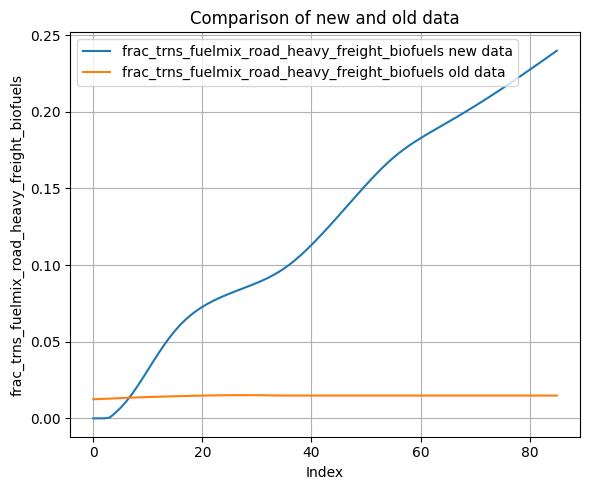

Comparing frac_trns_fuelmix_road_heavy_freight_diesel...


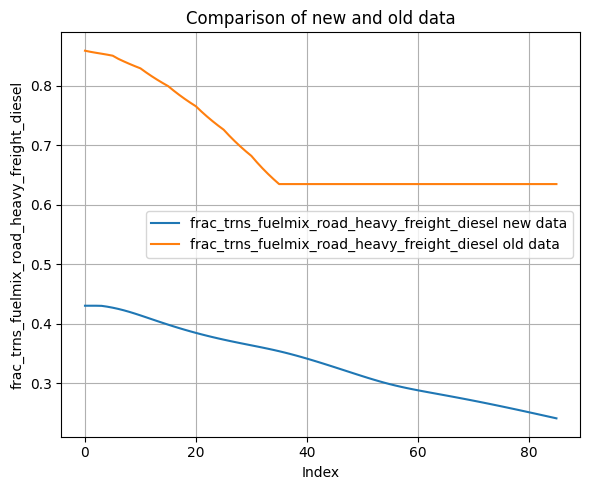

Comparing frac_trns_fuelmix_road_heavy_freight_electricity...


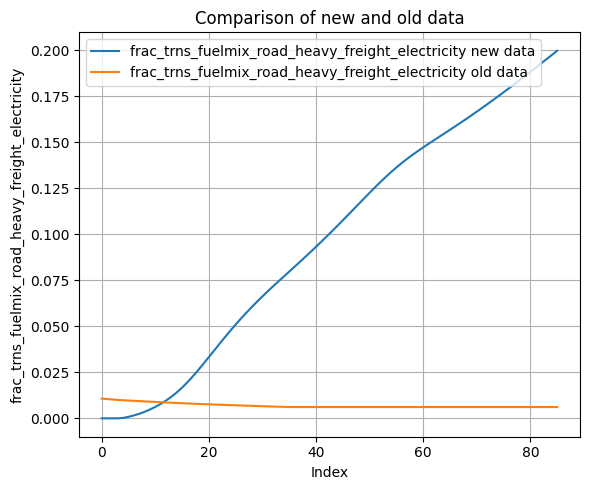

Comparing frac_trns_fuelmix_road_heavy_freight_gasoline...


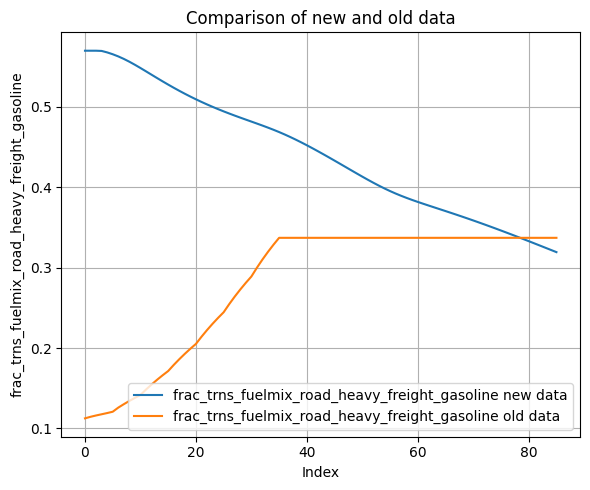

Comparing frac_trns_fuelmix_road_heavy_freight_hydrocarbon_gas_liquids...


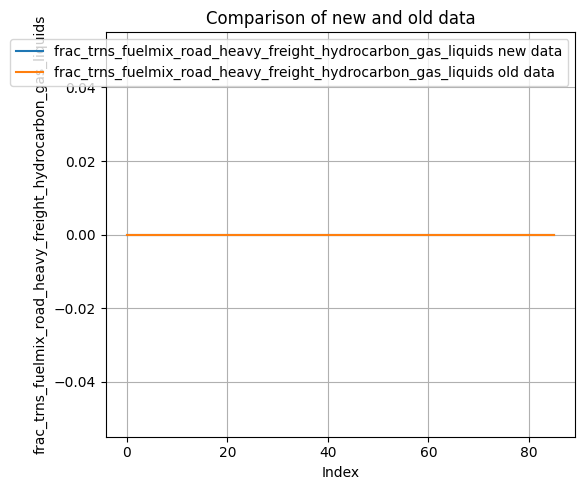

Comparing frac_trns_fuelmix_road_heavy_freight_hydrogen...


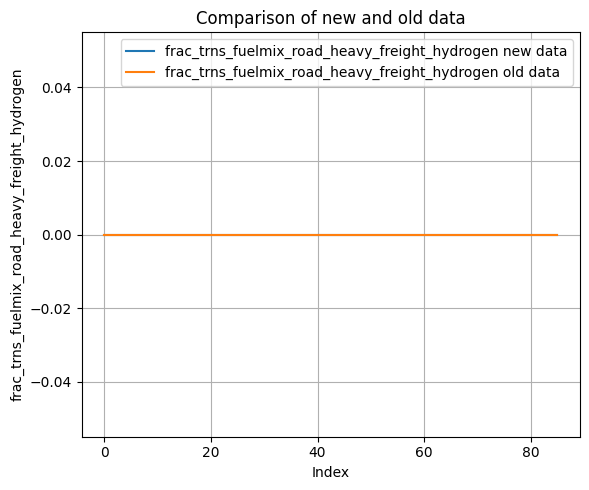

Comparing frac_trns_fuelmix_road_heavy_freight_natural_gas...


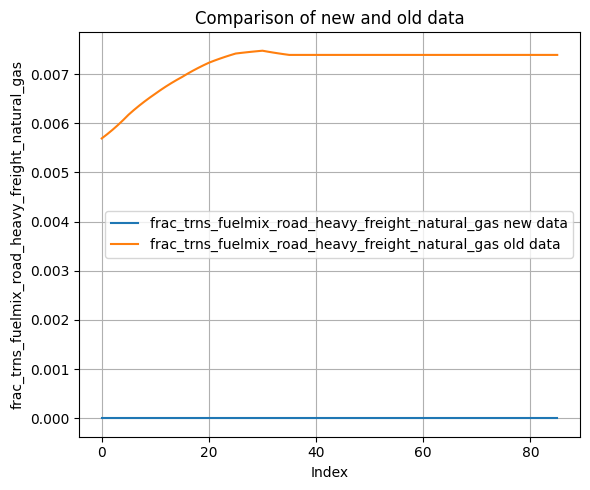

In [206]:
for var in frac_inen_energy_df_extended.columns:
    if var != 'year':
        print(f"Comparing {var}...")
        edau.compare_variables(frac_inen_energy_df_extended, uga_global_df, [var])

In [211]:
# Replace all -0.0 with +0.0 efficiently
frac_inen_energy_df_extended = frac_inen_energy_df_extended.where(frac_inen_energy_df_extended != 0, 0.0)
frac_inen_energy_df_extended = frac_inen_energy_df_extended.apply(np.abs)
frac_inen_energy_df_extended.to_csv(os.path.join(OUTPUT_DATA_DIR_PATH, f"frac_trns_fuelmix_{transport_cat}.csv"), index=False)